# EX 5: Medical Insurance Prediction

**Objective**: Learn more about Linear Regression and its different training techniques.
    
You will be using a medical insurance dataset.
Below are some informations to help **frame the problem**:

For a health insurance company to make money, it needs to collect more in yearly premiums than it spends on medical care to its beneﬁciaries.

As a result, insurers invest a great deal of time and money in developing models that accurately forecast medical expenses for the insured population.

Medical expenses are diﬃcult to estimate because the costliest conditions are rare and seemingly random.

Still, some conditions are more prevalent for certain segments of the population. For instance, lung cancer is more likely among smokers than non-smokers, and heart disease may be more likely among the obese.

The goal of this analysis is to use patient data to estimate the average medical care expenses for such population segments.

These estimates can be used to create actuarial tables that set the price of yearly premiums higher or lower, depending on the expected treatment costs.


## Collecting data

For this analysis, we will use a simulated dataset containing hypothetical medical expenses for patients in the United States.

This data was created using demographic statistics from the US Census Bureau, and approximately reﬂect real-world conditions.

The data includes **1,338 examples** of beneﬁciaries currently enrolled in the insurance plan, with features indicating characteristics of the patient as well as the total medical expenses charged to the plan for the calendar year. There are 6 features:

    • age: An integer indicating the age of the primary beneﬁciary (excluding those above 64 years, since they are generally covered by the government).

    • sex: The policy holder’s gender, either male or female.

    • bmi: The body mass index (BMI), which provides a sense of how over- or under-weight a person is relative to their height. BMI is equal to weight (in kilograms) divided by height (in meters) squared. An ideal BMI is within the range of 18.5 to 24.9.

    • children: An integer indicating the number of children/dependents covered by the insurance plan.

    • smoker: A yes or no categorical variable that indicates whether the insured regularly smokes tobacco.

    • region: The beneﬁciary’s place of residence in the US,divided into four geographic regions: northeast, southeast, southwest, or northwest.

It is important to give some thought to how these variables may be related to billed medical expenses.

For instance, we might expect that older people and smokers are at higher risk of large medical expenses. Unlike many other machine learning methods, in regression analysis, the relationships among the features are typically speciﬁed by the user rather than being detected automatically.

Let’s explore some of these potential relationships.


## Exploring and preparing the data

1. Load the data for analysis.
2. Show the structure of the data.
3. What feature is the dependent feature and which ones are the independent features? What is the type of each feature in the data?
4. How to analysis the dependent feature and why using this method?
5. Give two methods that describe if the dependent variable is normally distributed? Explain the distribution of the dependent feature.
6. Which of the independent features are categoricals in the data? Look into the distribution of each one. Explain the results.

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

df = pd.read_csv('insurance-2.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [51]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64


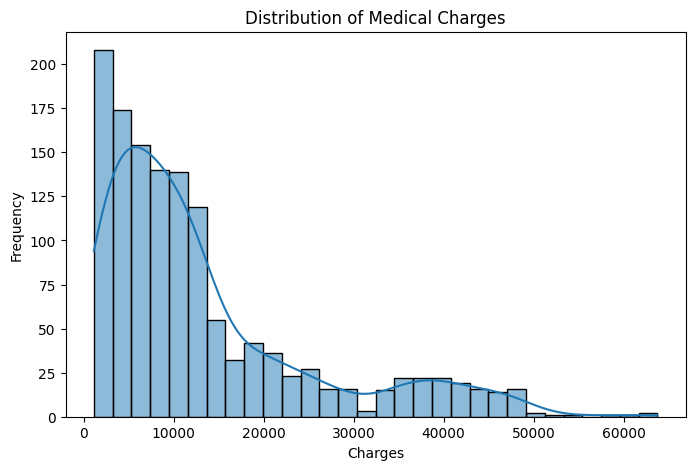

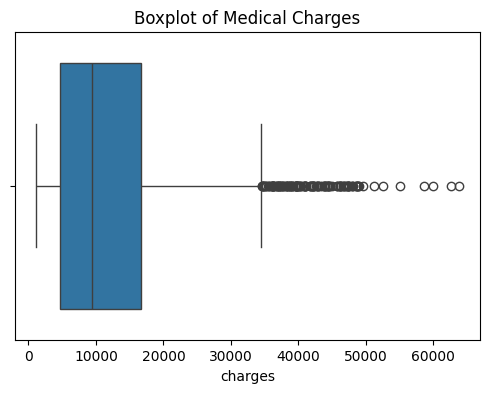

In [52]:
# Dependent and Independent features
# Dependent: charges
# Independent: age, sex, bmi, children, smoker, region

print(df["charges"].describe())

# Histogram
plt.figure(figsize=(8,5))
sns.histplot(df["charges"], kde=True)
plt.title("Distribution of Medical Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

# Check outliers
plt.figure(figsize=(6,4))
sns.boxplot(x=df["charges"])
plt.title("Boxplot of Medical Charges")
plt.show()

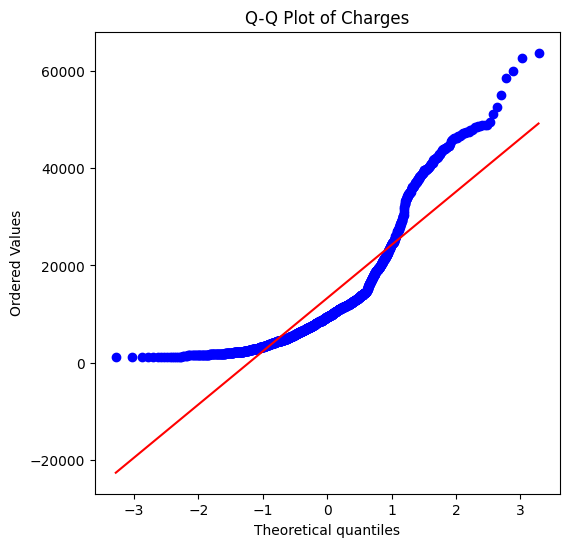

Shapiro-Wilk Test:
Statistic = 0.809116968813312, p-value = 7.227666101358283e-24


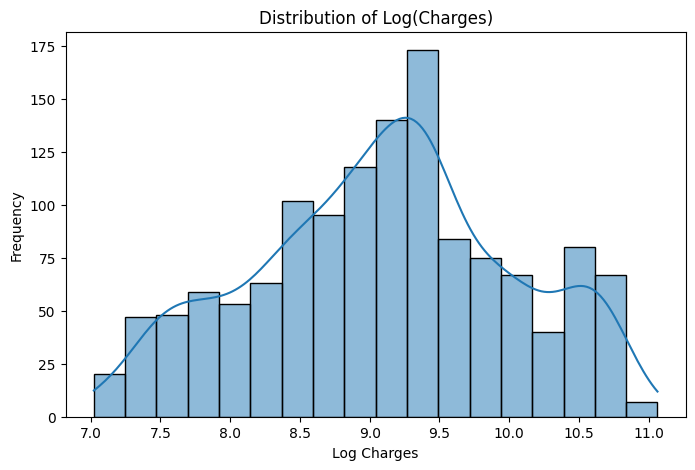

In [53]:
plt.figure(figsize=(6,6))
stats.probplot(df["charges"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Charges")
plt.show()

shapiro_test = stats.shapiro(df["charges"].sample(500, random_state=42))
print("Shapiro-Wilk Test:")
print(f"Statistic = {shapiro_test.statistic}, p-value = {shapiro_test.pvalue}")

df["log_charges"] = np.log(df["charges"])

plt.figure(figsize=(8,5))
sns.histplot(df["log_charges"], kde=True)
plt.title("Distribution of Log(Charges)")
plt.xlabel("Log Charges")
plt.ylabel("Frequency")
plt.show()


Value counts for sex:
sex
male      676
female    662
Name: count, dtype: int64


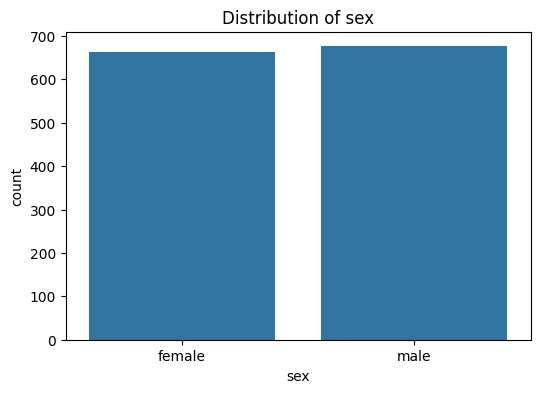


Value counts for smoker:
smoker
no     1064
yes     274
Name: count, dtype: int64


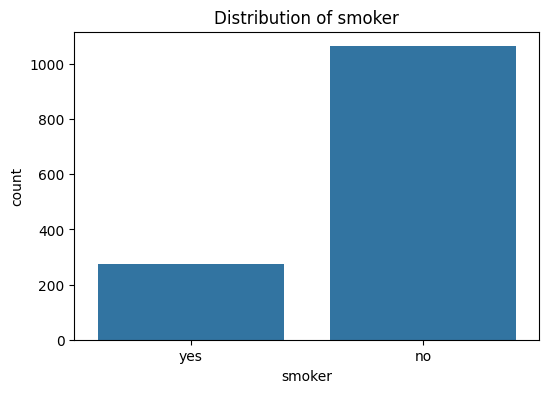


Value counts for region:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


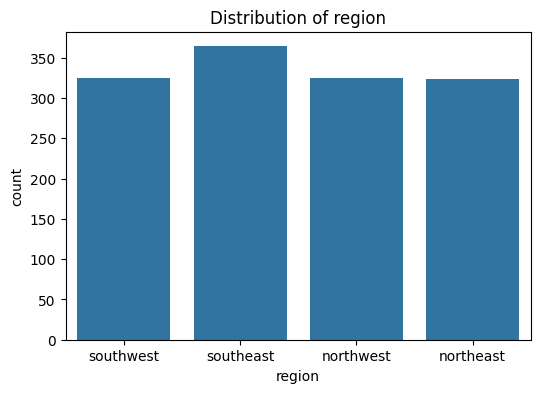

In [54]:
categorical_features = ["sex", "smoker", "region"]

for col in categorical_features:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())

    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

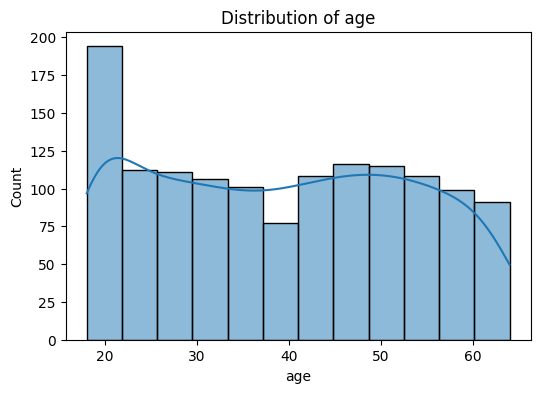

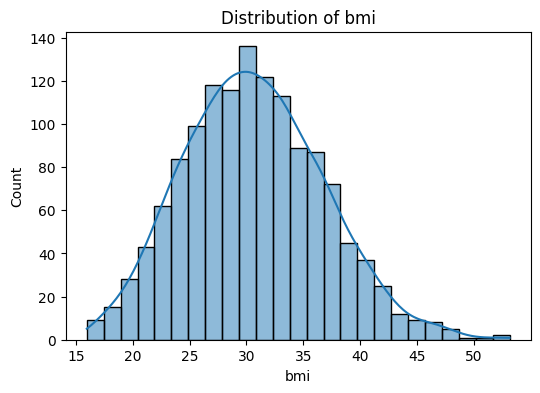

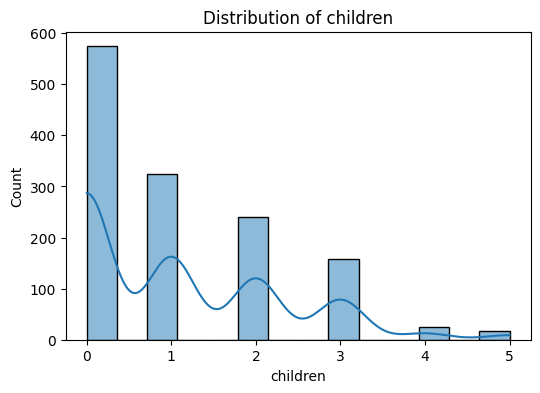

In [55]:
numerical_features = ["age", "bmi", "children"]

for col in numerical_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

## Exploring relationships among features

Before ﬁtting a regression model to data, it can be useful to determine how the independent variables are related to the dependent variable and each other.

A correlation matrix provides a quick overview of these relationships.Given a set of variables, it provides a correlation for each pairwise relationship.

   7. Create a correlation matrix for the four numeric variables in the insurance data frame.
   
   8. Is there any interesting relationship between features? Explain those associations


Correlation Matrix:


,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


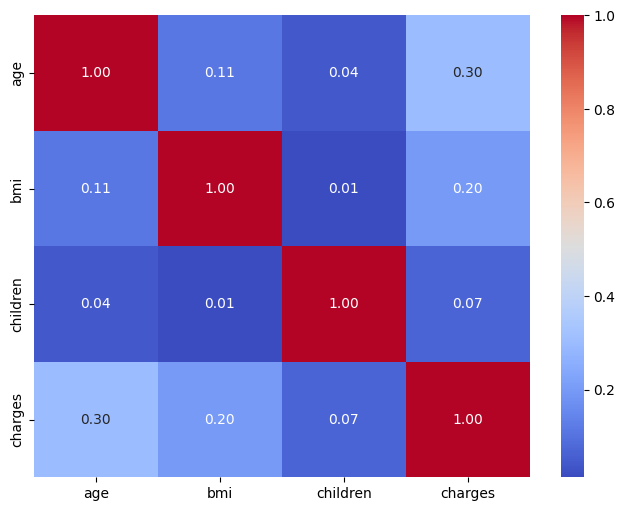

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric variables
numeric_df = df[["age", "bmi", "children", "charges"]]

# 7. Correlation matrix
corr_matrix = numeric_df.corr()
print("Correlation Matrix:")
display(corr_matrix)

# Heatmap for better visualization
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()


Medical charges increase mainly with age and BMI, while number of children has little effect, and the predictors are not strongly correlated with each other, making them suitable for regression modeling.

## Visualizing relationships among features

It can also be helpful to visualize the relationships among numeric features by using a scatterplot.

Although we could create a scatterplot for each possible relationship, doing so for a large number of features might become hard.

An alternative is to create a scatterplot matrix, which is simply a collection of scatterplots arranged in a grid.

It is used to detect patterns among three or more variables. The scatterplot matrix is not a true multidimensional visualization because only two features are examined at a time.

Still, it provides a general sense of how the data may be interrelated.

9. Use the scatter_matrix() function to create a scatterplot matrix for the four numeric features: age, bmi, children, and charges.

10. Do you notice any patterns in these plots? Explain.

11. To enhance the previous scatterplot matrix create the new one using the seaborn or plotly libraries. Do you notice any new patterns in these new graphics?

<Figure size 1000x1000 with 0 Axes>

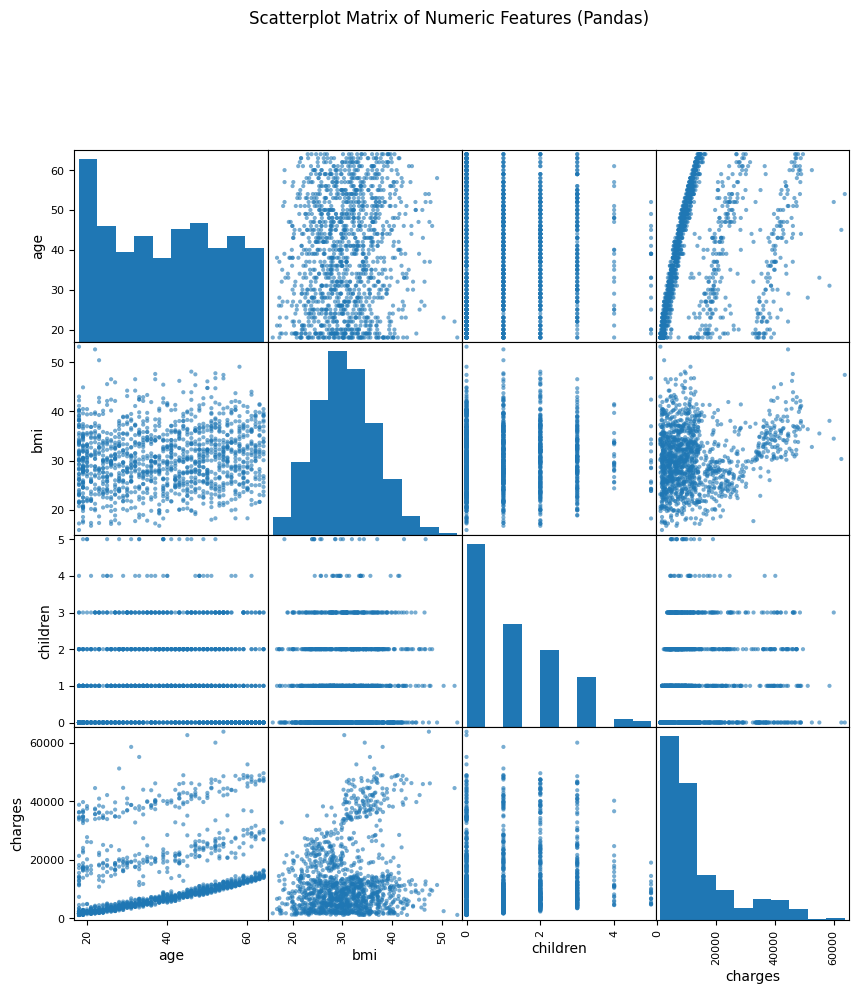

In [57]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Numeric features
numeric_df = df[["age", "bmi", "children", "charges"]]

# 9. Scatterplot matrix using pandas
plt.figure(figsize=(10,10))
scatter_matrix(numeric_df, alpha=0.6, figsize=(10,10), diagonal="hist")
plt.suptitle("Scatterplot Matrix of Numeric Features (Pandas)", y=1.02)
plt.show()

The most visible relationships are between charges and age, and charges and bmi. Other variable pairs show weak or no relationship.

```
# This is formatted as code
```



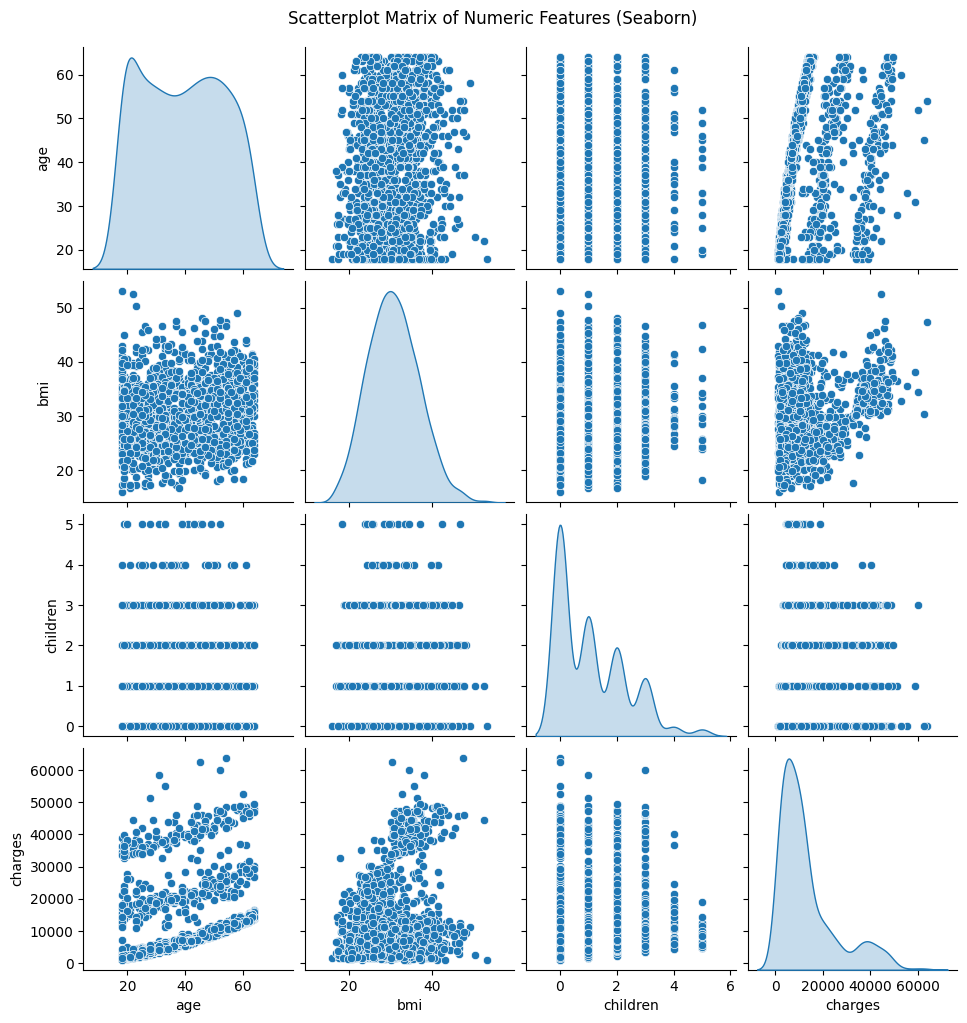

In [58]:
# 11. Enhanced scatterplot matrix using seaborn
sns.pairplot(numeric_df, diag_kind="kde")
plt.suptitle("Scatterplot Matrix of Numeric Features (Seaborn)", y=1.02)
plt.show()


The pandas scatterplot matrix shows that charges has a positive relationship with age and bmi, while children has little influence. Most independent variables are weakly correlated with each other.

The Seaborn-enhanced scatterplot matrix reveals a much stronger hidden pattern: smoker status dramatically affects medical charges. Smokers form a distinct group with significantly higher expenses, especially when combined with higher age and BMI. This indicates that smoker is one of the most important predictors in the dataset and should be treated carefully in the regression model.

## Dummy coding

To be able to use all variables in our regression model, we need to transform the categorical variables into numerical.
one way is by transforming every categorical variable into dummy variable.
Dummy coding is a commonly used method for converting a categorical variable into continuous variable.
Dummy, as the name suggests is a duplicate variable which represents one level of a categorical variable.
Presence of a level is represent by 1 and absence is represented by 0.
For every level present, one dummy variable will be created.
Look at the representation below to convert a categorical variable using dummy variable.

**data=pd.get_dummies(df, dtype=int)**

# Training a model on the data

1.   List item
2.   List item



To ﬁt a linear regression model to data with Python, the OLS function can be used. This is included in the statsmodels.api package, which you will need to import as sm. Use the OLS() syntax, to ﬁt a linear regression model to this data( Use all the available features).


## 1. statsmodels.api

Let's use the stats models package.

12. Use the OLS() syntax provided in here: https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html, to ﬁt a linear regression model to this data( Use all the available features). Name it “model”.

13. Show the estimated beta coeﬃcients. Explain the results. Why there are 11 coeﬃcients reported in addition to the intercept not 6?

14. What increase, or decrease will aﬀect the medical expenses for each additional child? or additional year of age? or unit increase of BMI?

15. Explain the eﬀect of medical expenses in numbers on each one of the 3 categorical features.

16. To evaluate the model performance, use the summary () function on the stored model.

17. Given the preceding two performance indicators, How the model is performing? explain.

In [59]:
import pandas as pd
import statsmodels.api as sm

# Dummy coding of categorical variables
data = pd.get_dummies(df, drop_first=True, dtype=int)

display(data.head())
print(data.columns)

,age,bmi,children,charges,log_charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,9.734176,0,1,0,0,1
1,18,33.770,1,1725.55230,7.453302,1,0,0,1,0
2,28,33.000,3,4449.46200,8.400538,1,0,0,1,0
3,33,22.705,0,21984.47061,9.998092,1,0,1,0,0
4,32,28.880,0,3866.85520,8.260197,1,0,1,0,0


Index(['age', 'bmi', 'children', 'charges', 'log_charges', 'sex_male',
       'smoker_yes', 'region_northwest', 'region_southeast',
       'region_southwest'],
      dtype='object')


In [60]:
X = data.drop("charges", axis=1)
y = data["charges"]

# Add intercept (constant term)
X = sm.add_constant(X)

# OLS model
model = sm.OLS(y, X).fit()

display(model.params)


,0
const,-81878.355198
age,-87.160945
bmi,206.141051
children,-537.768845
log_charges,9947.975073
sex_male,618.926548
smoker_yes,8386.170213
region_northwest,281.593194
region_southeast,528.767262
region_southwest,322.762497


Originally you had 6 independent features, but after dummy coding we had multuiple oher fields.

sex	1 dummy
smoker	1 dummy
region	3 dummies

new extra added features.

In [61]:
# 14
# Get OLS coefficients
ols_coefs = model.params
display(ols_coefs)

# Only numeric features
ols_coefs[["age", "bmi", "children"]]


,0
const,-81878.355198
age,-87.160945
bmi,206.141051
children,-537.768845
log_charges,9947.975073
sex_male,618.926548
smoker_yes,8386.170213
region_northwest,281.593194
region_southeast,528.767262
region_southwest,322.762497


,0
age,-87.160945
bmi,206.141051
children,-537.768845


In [62]:
#15
categorical_vars = [col for col in model.params.index
                    if "sex_" in col or "smoker_" in col or "region_" in col]

model.params[categorical_vars]


,0
sex_male,618.926548
smoker_yes,8386.170213
region_northwest,281.593194
region_southeast,528.767262
region_southwest,322.762497


In [ ]:
# A male policyholder spends about $619 more per year on medical expenses than a female policyholder, keeping all other variables constant.
# A smoker spends about $8,386 more per year on medical expenses than a non-smoker, holding everything else constant.

In [63]:
#16
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.883
Model:                            OLS   Adj. R-squared:                  0.883
Method:                 Least Squares   F-statistic:                     1117.
Date:                Thu, 29 Jan 2026   Prob (F-statistic):               0.00
Time:                        09:15:42   Log-Likelihood:                -13040.
No. Observations:                1338   AIC:                         2.610e+04
Df Residuals:                    1328   BIC:                         2.615e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -8.188e+04   1924.477  

The model performs very well. With an R² around 0.883, it explains most of the variation in medical charges.

The most influential predictor is smoking status, followed by age and BMI.

 The use of dummy coding allows categorical variables such as sex, smoker, and region to be incorporated numerically, which is why the number of coefficients is higher than the original number of features.

## 2. Scikit learn


Let's use the scikitLearn library.


18. Split the data between training and testing.


19. Use the scikitLearn library to implement the **LinearRegression** function, from sklearn.linear_model, based on the Normal equation to find the value of the weights that minimizes the MSE. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

20. Use the scikitLearn library to implement the **SGDRegressor** function, from sklearn.linear_model, based on the stochastic Gradient descent to find the value of the weights that minimizes the MSE. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html#

21. Use SGDRegressor function, from sklearn.linear_model, to implement a similation of the Mini batch Gradient descent.


22. What are the key hyperparameters of each implementation?

23. Find different metrics to evaluate your regression model performance.

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd


In [66]:
data = pd.get_dummies(df, dtype=int)

X = data.drop("charges", axis=1)
y = data["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [67]:
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)

# Metrics
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression (Normal Equation)")
print("MSE:", mse_lr)
print("RMSE:", rmse_lr)
print("MAE:", mae_lr)
print("R²:", r2_lr)

Linear Regression (Normal Equation)
MSE: 16074369.930600494
RMSE: 4009.285463845209
MAE: 2895.135336894084
R²: 0.8964605393155676


In [68]:
# SDG
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [69]:
sgd = SGDRegressor(
    loss="squared_error",
    max_iter=1000,
    learning_rate="optimal",
    eta0=0.01,
    random_state=42
)

sgd.fit(X_train_scaled, y_train)

y_pred_sgd = sgd.predict(X_test_scaled)

mse_sgd = mean_squared_error(y_test, y_pred_sgd)
rmse_sgd = np.sqrt(mse_sgd)
mae_sgd = mean_absolute_error(y_test, y_pred_sgd)
r2_sgd = r2_score(y_test, y_pred_sgd)

print("\nSGDRegressor (Stochastic GD)")
print("MSE:", mse_sgd)
print("RMSE:", rmse_sgd)
print("MAE:", mae_sgd)
print("R²:", r2_sgd)



SGDRegressor (Stochastic GD)
MSE: 57349138.072876334
RMSE: 7572.921369780379
MAE: 5906.5392898143855
R²: 0.6305983467831735


In [70]:
#21
sgd = SGDRegressor(
    loss="squared_error",
    learning_rate="constant",
    eta0=0.01,
    max_iter=1,
    warm_start=True,
    random_state=42
)

batch_size = 32
n_epochs = 50

for epoch in range(n_epochs):
    # Shuffle data at each epoch
    indices = np.random.permutation(len(X_train_scaled))
    X_shuffled = X_train_scaled[indices]
    y_shuffled = y_train.iloc[indices]

    # Mini-batches
    for i in range(0, len(X_train_scaled), batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        sgd.partial_fit(X_batch, y_batch)

y_pred_minibatch = sgd.predict(X_test_scaled)

mse_mb = mean_squared_error(y_test, y_pred_minibatch)
rmse_mb = np.sqrt(mse_mb)
mae_mb = mean_absolute_error(y_test, y_pred_minibatch)
r2_mb = r2_score(y_test, y_pred_minibatch)

print("\nSGDRegressor (Mini-batch GD)")
print("MSE:", mse_mb)
print("RMSE:", rmse_mb)
print("MAE:", mae_mb)
print("R²:", r2_mb)



SGDRegressor (Mini-batch GD)
MSE: 18272745.091229044
RMSE: 4274.663155294115
MAE: 3184.6425196846935
R²: 0.8823001971375379


# HYPERPARAMETERS

**LinearRegression**
fit_intercept,
n_jobs,
positive

**SDG**
loss,
learning_rate,
max_iter,
alpha,
penalty,
tol,
eta0,
random_state,
